<a href="https://colab.research.google.com/github/Sammy12357/SafeScan-Android-main/blob/main/SafeScanQR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Your authenticated API endpoint
urlhaus_feed = "https://urlhaus-api.abuse.ch/v2/files/exports/e57d45cb5edc90b7ebb55fad81e5760bf07277d949863279/recent.csv"

urlhaus_columns = ['id', 'dateadded', 'url', 'url_status', 'last_online', 'threat', 'tags', 'urlhaus_link', 'reporter']

# Read the CSV and assign the column names manually
urlhaus_df = pd.read_csv(urlhaus_feed, quotechar='"', encoding='utf-8', on_bad_lines='skip', names=urlhaus_columns)

# Extract just the URLs into a clean Python list
malicious_urls = urlhaus_df['url'].dropna().tolist()
print(f"Loaded {len(malicious_urls)} malicious URLs!")

Loaded 26009 malicious URLs!


In [ ]:
import pandas as pd
import requests

# 1. Pull from Mitchell Krog's Phishing.Database
github_feed = "https://raw.githubusercontent.com/mitchellkrogza/Phishing.Database/master/phishing-links-ACTIVE.txt"
response = requests.get(github_feed)
github_malicious_urls = response.text.splitlines()
print(f"Loaded {len(github_malicious_urls)} active phishing URLs from GitHub.")

Loaded 789054 active phishing URLs from GitHub.


In [ ]:
# Combine your lists (add phishstats_urls here if you pulled it)
all_malicious_urls = malicious_urls + github_malicious_urls

# Deduplicate by converting to a set, then back to a list
unique_malicious_urls = list(set(all_malicious_urls))

print(f"Total combined URLs: {len(all_malicious_urls)}")
print(f"Total unique URLs to train on: {len(unique_malicious_urls)}")

Total combined URLs: 815063
Total unique URLs to train on: 815063


In [ ]:
import pandas as pd

# Fetch the latest daily Tranco Top 1 Million list
tranco_url = "https://tranco-list.eu/top-1m.csv.zip"

# Pandas can read zipped CSVs directly into memory
benign_df = pd.read_csv(tranco_url, names=['rank', 'url'])

# Extract just the URLs into a clean Python list
benign_urls = benign_df['url'].tolist()
print(f"Loaded {len(benign_urls)} benign URLs!")

Loaded 1000000 benign URLs!


In [ ]:
# Cut the benign list to match the exact length of the malicious list
balanced_benign_urls = benign_urls[:len(unique_malicious_urls)]

print(f"Malicious URLs: {len(unique_malicious_urls)}")
print(f"Benign URLs: {len(balanced_benign_urls)}")
# Both will now perfectly equal 817,952

Malicious URLs: 814953
Benign URLs: 814953


### Generating QR Code Images from URLs
We will now convert the balanced benign URLs and the unique malicious URLs into actual QR code images and store their file paths.

In [ ]:
# Check remaining disk space in /content
import shutil
total, used, free = shutil.disk_usage("/")
print(f"Total: {total // (2**30)} GiB")
print(f"Used: {used // (2**30)} GiB")
print(f"Free: {free // (2**30)} GiB")

print(f"\nEstimated QR codes you could fit in free space: {free // (2048):,}") # Assuming 2KB per image

Total: 235 GiB
Used: 42 GiB
Free: 192 GiB

Estimated QR codes you could fit in free space: 101,099,412


### Parallelizing QR Code Generation with Multiprocessing

To significantly speed up the QR code generation, especially for large datasets, we can leverage Python's `multiprocessing` module. QR code generation is a CPU-bound task (it uses CPU cycles rather than waiting for I/O), making it an excellent candidate for parallel processing. By using multiple CPU cores simultaneously, we can generate many QR codes concurrently.

We'll define a helper function to generate a single QR code and then use a `multiprocessing.Pool` to map this function over our list of URLs.

In [ ]:
!pip install qrcode[pil]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.6 MB/s eta 0:00:00


In [ ]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import pickle
import qrcode

from google.colab import drive


drive.mount('/content/drive')

path = kagglehub.dataset_download("samahsadiq/benign-and-malicious-qr-codes")

def fetch_qr_data(data_path):
    data=[]
    for label in ['benign', 'malicious']:
        # Updated path to handle nested folders
        folder_path = os.path.join(data_path, 'QR codes', label, label)
        if os.path.exists(folder_path):
            for img_name in os.listdir(folder_path):
                data.append({
                    'file_path': os.path.join(folder_path, img_name),
                    'label': label
                })
    return pd.DataFrame(data)

qr_data = fetch_qr_data(path)
qr_data.head()


path_1_5 = '/content/drive/MyDrive/1000 QR Images of Malicious and Benign QR codes/1000 QR Images of Malicious and Benign QR codes 2025/benign_qr_images_500'

def fetch_qr_data_1_5(data_path):
    data=[]
    # Assume data_path directly contains benign images
    if os.path.exists(data_path):
      for img_name in os.listdir(data_path):
        data.append({
            'file_path': os.path.join(data_path, img_name),
            'label': 'benign'
        })
    return pd.DataFrame(data)

qr_dat_1_5 = fetch_qr_data_1_5(path_1_5)
qr_dat_1_5.head()


path_1_9 = '/content/drive/MyDrive/1000 QR Images of Malicious and Benign QR codes/1000 QR Images of Malicious and Benign QR codes 2025/malicious_qr_images_500'

def fetch_qr_data_1_9(data_path):
    data=[]
    # Assume data_path directly contains malicious images
    if os.path.exists(data_path):
      for img_name in os.listdir(data_path):
        data.append({
            'file_path': os.path.join(data_path, img_name),
            'label': 'malicious'
        })
    return pd.DataFrame(data)

qr_dat_1_9 = fetch_qr_data_1_9(path_1_9)
qr_dat_1_9.head()

path_2 = '/content/drive/MyDrive/QuishingDataset'

def fetch_qr_data_2(data_path):
    qr_codes_file = os.path.join(data_path, 'qr_codes_29.pickle')
    labels_file = os.path.join(data_path, 'qr_codes_29_labels.pickle')

    data = []
    if os.path.exists(qr_codes_file) and os.path.exists(labels_file):
        try:
            # Load image arrays and labels from pickle files
            images = pickle.load(open(qr_codes_file, 'rb'))
            labels_int = pickle.load(open(labels_file, 'rb'))

            if len(images) != len(labels_int):
                print(f"Warning: Mismatch in length between image data and labels for path_2. Returning empty DataFrame.")
                return pd.DataFrame(columns=['file_path', 'label'])

            # Create a temporary directory to save images for ImageDataGenerator
            temp_image_dir = os.path.join('/tmp', 'qr_data_2_images')
            os.makedirs(temp_image_dir, exist_ok=True)

            for i, (img_array, label_int) in enumerate(zip(images, labels_int)):
                # Convert numerical label to string (assuming 0=benign, 1=malicious)
                label_str = 'benign' if label_int == 0 else 'malicious'

                # Create a unique filename for each image
                filename = f"qr_image_{i}_{label_str}.png"
                filepath = os.path.join(temp_image_dir, filename)

                # Save the numpy array as an image file
                # Assuming the img_array is grayscale (69, 69) and values are 0-255 or 0-1
                plt.imsave(filepath, img_array, cmap='gray') # Use cmap='gray' for single channel images

                data.append({
                    'file_path': filepath,
                    'label': label_str
                })
            return pd.DataFrame(data)
        except Exception as e:
            print(f"Error processing pickle files for path_2: {e}")
            return pd.DataFrame(columns=['file_path', 'label'])
    else:
        print(f"Warning: Expected pickle files '{os.path.basename(qr_codes_file)}' and '{os.path.basename(labels_file)}' not found in {data_path}. Returning empty DataFrame.")
        return pd.DataFrame(columns=['file_path', 'label'])

qr_dat_2 = fetch_qr_data_2(path_2)
qr_dat_2.head()

def fetch_custom_benign_qr_data(output_dir='/content/custom_benign'):
    os.makedirs(output_dir, exist_ok=True)

    # Add your specific GitHub, LinkedIn, and standard links here
    links = [
        "https://github.com/",
        "https://www.linkedin.com/",
        "https://stackoverflow.com/",
        "https://www.python.org/",
        "Standard plain text payload"
    ] * 20 # Multiplies to generate 100 images

    data = []
    for i, link_data in enumerate(links):
        # Generates standard, benign QR codes
        img = qrcode.make(link_data)
        filepath = os.path.join(output_dir, f"custom_benign_{i}.png")
        img.save(filepath)
        data.append({
            'file_path': filepath,
            'label': 'benign'
        })
    print(f"Saved {len(links)} diverse QR codes to {output_dir}")
    return pd.DataFrame(data)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


100%|██████████| 217M/217M [00:13<00:00, 16.6MB/s]

Extracting files...


In [ ]:
import os
import pandas as pd
import zipfile

# 1. Unpack the zip file from your Drive directly into Colab's local disk
zip_path = '/content/drive/MyDrive/massive_qr_dataset.zip'
extract_path = '/content/url_qr_codes/'

print("Unzipping dataset... this will take a few minutes.")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Unzipping complete!")

# 2. Rebuild the mapping dataframe by scanning the extracted folders
data = []
for root, _, files in os.walk(extract_path):
    for file in files:
        if file.endswith('.png'):
            # The folder names ('benign_parallel' or 'malicious_parallel') tell us the label
            label = 'benign' if 'benign' in root else 'malicious'
            data.append({'file_path': os.path.join(root, file), 'label': label})

url_qr_metadata_parallel = pd.DataFrame(data)
print(f"Rebuilt dataframe with {len(url_qr_metadata_parallel)} images!")

Unzipping dataset... this will take a few minutes.
Unzipping complete!
Rebuilt dataframe with 1629674 images!


In [ ]:
import os
print(os.listdir(path))
print(os.listdir(path_1_5))
print(os.listdir(path_1_9))
print(os.listdir(path_2))

['QR codes']
['qr_114_benign_images.png', 'qr_140_benign_images.png', 'qr_104_benign_images.png', 'qr_66_benign_images.png', 'qr_30_benign_images.png', 'qr_9_benign_images.png', 'qr_64_benign_images.png', 'qr_46_benign_images.png', 'qr_6_benign_images.png', 'qr_23_benign_images.png', 'qr_112_benign_images.png', 'qr_91_benign_images.png', 'qr_2_benign_images.png', 'qr_75_benign_images.png', 'qr_18_benign_images.png', 'qr_55_benign_images.png', 'qr_19_benign_images.png', 'qr_8_benign_images.png', 'qr_89_benign_images.png', 'qr_72_benign_images.png', 'qr_123_benign_images.png', 'qr_52_benign_images.png', 'qr_74_benign_images.png', 'qr_117_benign_images.png', 'qr_136_benign_images.png', 'qr_125_benign_images.png', 'qr_118_benign_images.png', 'qr_100_benign_images.png', 'qr_1_benign_images.png', 'qr_37_benign_images.png', 'qr_50_benign_images.png', 'qr_73_benign_images.png', 'qr_87_benign_images.png', 'qr_141_benign_images.png', 'qr_62_benign_images.png', 'qr_102_benign_images.png', 'qr_107

In [ ]:
def load_qr_data(path):
  csv_path = 'qr_data.csv'
  if not os.path.isfile(csv_path):
      qr_data = fetch_qr_data(path)
      qr_data.to_csv(csv_path, index=False)
  return pd.read_csv(csv_path)

def load_qr_data_1_5(path_1_5):
  csv_path_1_5 = 'qr_dat_1_5.csv'
  if not os.path.isfile(csv_path_1_5):
      qr_dat_1_5_temp = fetch_qr_data_1_5(path_1_5)
      qr_dat_1_5_temp.to_csv(csv_path_1_5, index=False)
  return pd.read_csv(csv_path_1_5)

def load_qr_data_1_9(path_1_9):
  csv_path_1_9 = 'qr_dat_1_9.csv'
  if not os.path.isfile(csv_path_1_9):
      qr_dat_1_9_temp = fetch_qr_data_1_9(path_1_9)
      qr_dat_1_9_temp.to_csv(csv_path_1_9, index=False)
  return pd.read_csv(csv_path_1_9)

def load_qr_data_2(path_2):
  csv_path_2 = 'qr_dat_2.csv'
  if not os.path.isfile(csv_path_2):
      qr_dat_2_temp = fetch_qr_data_2(path_2)
      qr_dat_2_temp.to_csv(csv_path_2, index=False)
  return pd.read_csv(csv_path_2)

def load_custom_benign_qr_data():
  csv_path_custom_benign = 'custom_benign_qr_data.csv'
  if not os.path.isfile(csv_path_custom_benign):
      custom_benign_qr_data_temp = fetch_custom_benign_qr_data()
      custom_benign_qr_data_temp.to_csv(csv_path_custom_benign, index=False)
  return pd.read_csv(csv_path_custom_benign)

In [ ]:
output_dir = '/content/custom_benign'
os.makedirs(output_dir, exist_ok=True)

# Add your specific GitHub, LinkedIn, and standard links here
links = [
    "https://github.com/",
    "https://www.linkedin.com/",
    "https://stackoverflow.com/",
    "https://www.python.org/",
    "Standard plain text payload"
] * 20 # Multiplies to generate 100 images

for i, data in enumerate(links):
    # Generates standard, benign QR codes
    img = qrcode.make(data)
    img.save(os.path.join(output_dir, f"custom_benign_{i}.png"))

print(f"Saved {len(links)} diverse QR codes to {output_dir}")

Saved 100 diverse QR codes to /content/custom_benign


In [ ]:
# Remove the old incorrect CSVs and reload
if os.path.exists('qr_data.csv'):
    os.remove('qr_data.csv')

if os.path.exists('qr_dat_1_5.csv'):
    os.remove('qr_dat_1_5.csv')

if os.path.exists('qr_dat_1_9.csv'):
    os.remove('qr_dat_1_9.csv')

if os.path.exists('qr_dat_2.csv'):
    os.remove('qr_dat_2.csv')

if os.path.exists('custom_benign_qr_data.csv'):
    os.remove('custom_benign_qr_data.csv')

qr_data = load_qr_data(path)
qr_data_1_5 = load_qr_data_1_5(path_1_5)
qr_data_1_9 = load_qr_data_1_9(path_1_9)
qr_data_2 = load_qr_data_2(path_2)
custom_benign_qr_data = load_custom_benign_qr_data()

qr_codes = pd.concat([qr_data, qr_data_1_5, qr_data_1_9, qr_data_2, custom_benign_qr_data], ignore_index=True)
print(qr_codes['label'].value_counts())

Saved 100 diverse QR codes to /content/custom_benign
label
benign       105605
malicious    105482
Name: count, dtype: int64


In [ ]:
# FINAL MERGE
# This combines all image-based sources + your newly generated URL-based QR codes (800k+)
qr_codes = pd.concat([qr_data, qr_data_1_5, qr_data_1_9, qr_data_2, custom_benign_qr_data], ignore_index=True)
all_qr_data = pd.concat([qr_codes, url_qr_metadata_parallel], ignore_index=True)

# Separating into final sets
benign_subset = all_qr_data[all_qr_data['label'] == 'benign'].reset_index(drop=True)
malicious_subset = all_qr_data[all_qr_data['label'] == 'malicious'].reset_index(drop=True)

print(f"Final Master Dataset size: {len(all_qr_data):,}")
print(f"Total Benign: {len(benign_subset):,}")
print(f"Total Malicious: {len(malicious_subset):,}")

# Display samples to verify
display(all_qr_data.sample(5))

Final Master Dataset size: 1,840,761
Total Benign: 920,558
Total Malicious: 920,203


,file_path,label
35018,/root/.cache/kagglehub/datasets/samahsadiq/ben...,benign
262649,/content/url_qr_codes/benign_parallel/shard_12...,benign
1595734,/content/url_qr_codes/malicious_parallel/shard...,malicious
1133148,/content/url_qr_codes/malicious_parallel/shard...,malicious
1366918,/content/url_qr_codes/malicious_parallel/shard...,malicious


In [ ]:
import pandas as pd
import os

# 1. Re-merge the datasets to ensure 'all_qr_data' includes the parallel generated QRs
# We use the dataframes loaded in the previous successful steps
qr_codes_initial = pd.concat([qr_data, qr_data_1_5, qr_data_1_9, qr_data_2, custom_benign_qr_data], ignore_index=True)
all_qr_data = pd.concat([qr_codes_initial, url_qr_metadata_parallel], ignore_index=True)

# 2. Separate them by label
benign_subset = all_qr_data[all_qr_data['label'] == 'benign'].reset_index(drop=True)
malicious_subset = all_qr_data[all_qr_data['label'] == 'malicious'].reset_index(drop=True)

# 3. Summary of the split
print(f"Total Merged Records: {len(all_qr_data):,}")
print(f"Benign Records: {len(benign_subset):,}")
print(f"Malicious Records: {len(malicious_subset):,}")

# Displaying the first few rows of each to confirm separation
print("\n--- Benign Sample ---")
display(benign_subset.head())

print("\n--- Malicious Sample ---")
display(malicious_subset.head())

Total Merged Records: 1,840,761
Benign Records: 920,558
Malicious Records: 920,203

--- Benign Sample ---


,file_path,label
0,/root/.cache/kagglehub/datasets/samahsadiq/ben...,benign
1,/root/.cache/kagglehub/datasets/samahsadiq/ben...,benign
2,/root/.cache/kagglehub/datasets/samahsadiq/ben...,benign
3,/root/.cache/kagglehub/datasets/samahsadiq/ben...,benign
4,/root/.cache/kagglehub/datasets/samahsadiq/ben...,benign



--- Malicious Sample ---


,file_path,label
0,/root/.cache/kagglehub/datasets/samahsadiq/ben...,malicious
1,/root/.cache/kagglehub/datasets/samahsadiq/ben...,malicious
2,/root/.cache/kagglehub/datasets/samahsadiq/ben...,malicious
3,/root/.cache/kagglehub/datasets/samahsadiq/ben...,malicious
4,/root/.cache/kagglehub/datasets/samahsadiq/ben...,malicious


In [ ]:
print(f"Contents of {path_2}: {os.listdir(path_2)}")

# Check direct benign/malicious folders for path_1_5 and path_1_9
if os.path.exists(path_1_5):
    print(f"Contents of {path_1_5}: {os.listdir(path_1_5)[:5]} (showing first 5 if many)")
else:
    print(f"{path_1_5} does not exist.")

if os.path.exists(path_1_9):
    print(f"Contents of {path_1_9}: {os.listdir(path_1_9)[:5]} (showing first 5 if many)")
else:
    print(f"{path_1_9} does not exist.")


print(f"Contents of {path}: {os.listdir(path)[:5]}")

Contents of /content/drive/MyDrive/QuishingDataset: ['qr_codes_29.pickle', 'qr_codes_29_labels.pickle']
Contents of /content/drive/MyDrive/1000 QR Images of Malicious and Benign QR codes/1000 QR Images of Malicious and Benign QR codes 2025/benign_qr_images_500: ['qr_114_benign_images.png', 'qr_140_benign_images.png', 'qr_104_benign_images.png', 'qr_66_benign_images.png', 'qr_30_benign_images.png'] (showing first 5 if many)
Contents of /content/drive/MyDrive/1000 QR Images of Malicious and Benign QR codes/1000 QR Images of Malicious and Benign QR codes 2025/malicious_qr_images_500: ['qr_8_malicious_images.png', 'qr_1_malicious_images.png', 'qr_3_malicious_images.png', 'qr_0_malicious_images.png', 'qr_4_malicious_images.png'] (showing first 5 if many)
Contents of /kaggle/input/benign-and-malicious-qr-codes: ['QR codes']


In [ ]:
base_path = os.path.join(path, 'QR codes')
for label in ['benign', 'malicious']:
    folder = os.path.join(base_path, label)
    if os.path.exists(folder):
        content = os.listdir(folder)
        print(f"{label} contains {len(content)} items: {content[:5]}")
        # Check if the single item is a directory
        if len(content) == 1:
            subpath = os.path.join(folder, content[0])
            if os.path.isdir(subpath):
                print(f"  - '{content[0]}' is a directory containing {len(os.listdir(subpath))} files.")

benign contains 1 items: ['benign']
  - 'benign' is a directory containing 100000 files.
malicious contains 1 items: ['malicious']
  - 'malicious' is a directory containing 100000 files.


In [ ]:
qr_codes.describe()

,file_path,label
count,211087,211087
unique,211087,2
top,/content/custom_benign/custom_benign_99.png,benign
freq,1,105605


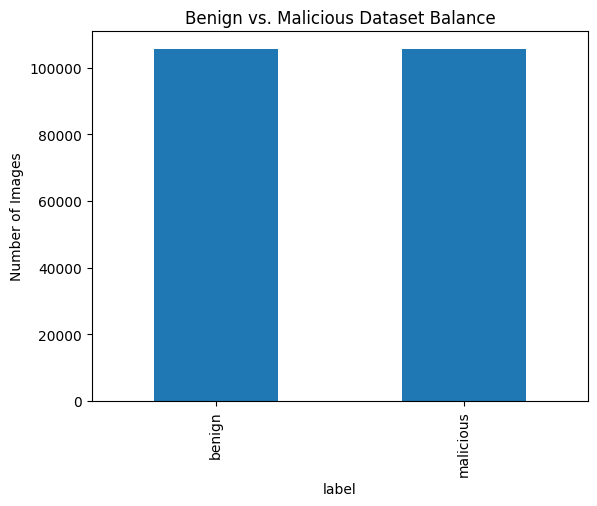

In [ ]:
qr_codes['label'].value_counts().plot(kind='bar')
plt.title('Benign vs. Malicious Dataset Balance')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
np.random.seed(42)

def manual_stratified_split(df, test_ratio):
  benign_df = df[df['label'] == 'benign']
  malicious_df = df[df['label'] == 'malicious']

  def split_train_test(df):
    shuffled_indices = np.random.permutation(len(df))
    test_set_size = int(len(df) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return df.iloc[train_indices], df.iloc[test_indices]

  benign_train, benign_test = split_train_test(benign_df)
  malicious_train, malicious_test = split_train_test(malicious_df)

  train_set = pd.concat([benign_train, malicious_train]).sample(frac=1, random_state=42).reset_index(drop=True)
  test_set = pd.concat([benign_test, malicious_test]).sample(frac=1, random_state=42).reset_index(drop=True)

  return train_set, test_set

In [ ]:
train_set, test_set = manual_stratified_split(all_qr_data, 0.2)

from sklearn.model_selection import train_test_split

# Split the train_set into a smaller train_set and a new val_set
train_set, val_set = train_test_split(
    train_set,
    test_size=0.2,
    random_state=42,
    stratify=train_set['label']
)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the Cutout function
def qrcode_cutout(image):
    # 50% chance to apply the blackout box
    if np.random.rand() > 0.5:
        return image

    # We will black out a random 40x40 square
    box_size = 40
    h, w, _ = image.shape
    y = np.random.randint(0, h - box_size)
    x = np.random.randint(0, w - box_size)

    # Apply the black box
    image[y:y+box_size, x:x+box_size, :] = 0
    return image

# 2. Update your ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='constant',
    cval=255,
    preprocessing_function=qrcode_cutout  # <-- Added right here!
)

# ... [Keep the rest of your train_ds, val_ds, and test_ds code exactly the same] ...

# Note: Use a larger image size like 224x224 for better CNN performance
img_height, img_width = 224, 224
batch_size = 64

train_ds = datagen.flow_from_dataframe(
    dataframe=train_set,
    x_col='file_path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # Changed to 'binary' for binary_crossentropy
    shuffle=True,
    seed=42,
)

val_ds = datagen.flow_from_dataframe(
    dataframe=val_set,
    x_col='file_path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # Changed to 'binary'
    shuffle=False,
)

test_ds = datagen.flow_from_dataframe(
    dataframe=test_set,
    x_col='file_path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # Changed to 'binary'
    shuffle=False,
)

Found 1178088 validated image filenames belonging to 2 classes.
Found 294522 validated image filenames belonging to 2 classes.
Found 368151 validated image filenames belonging to 2 classes.


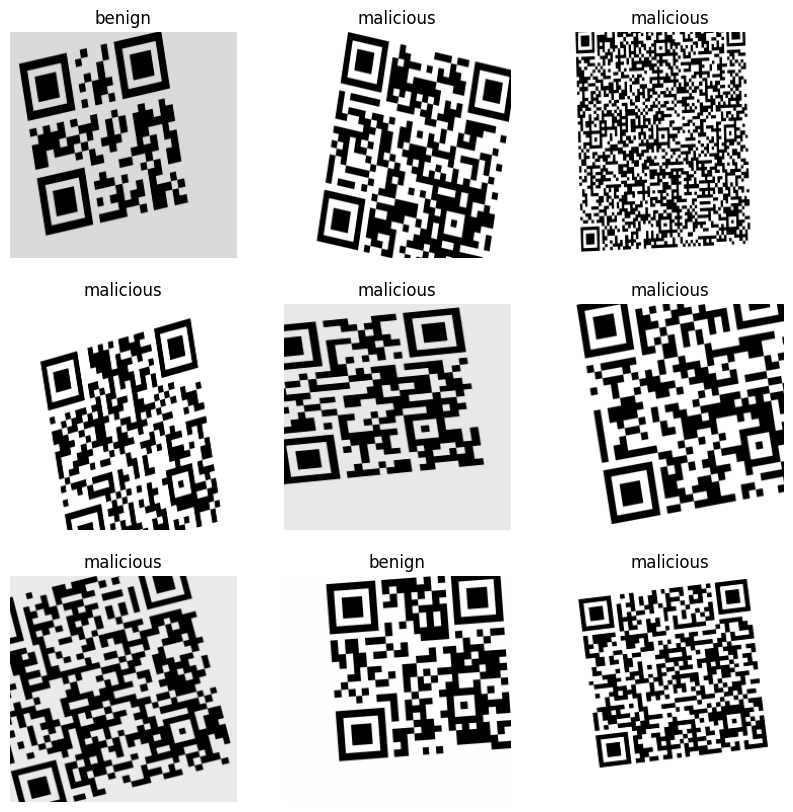

In [ ]:
class_names = ('benign', 'malicious')
plt.figure(figsize=(10, 10))

images, labels = next(train_ds)

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    # Use argmax to get the index if labels are one-hot encoded
    label_idx = np.argmax(labels[i]) if labels[i].ndim > 0 else int(labels[i])
    plt.title(class_names[label_idx])
    plt.axis("off")
plt.show()

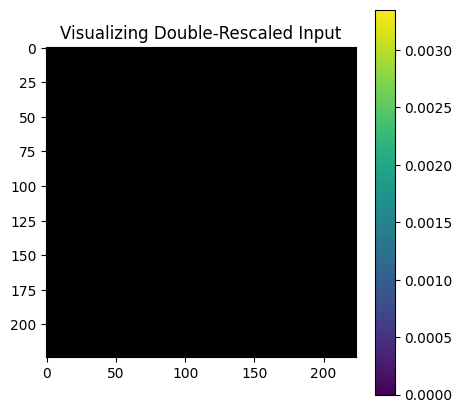

Max pixel value after double rescaling: 0.003352557076141238


In [ ]:
import matplotlib.pyplot as plt
# Grab one batch
sample_images, _ = next(train_ds)

rescaling_layer = tf.keras.layers.Rescaling(1./255)
processed_imgs = rescaling_layer(sample_images)

plt.figure(figsize=(5,5))
plt.title("Visualizing Double-Rescaled Input")
plt.imshow(processed_imgs[0])
plt.colorbar()
plt.show()
print(f"Max pixel value after double rescaling: {np.max(processed_imgs[0])}")

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Block 1
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 2
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 3 (New)
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Block 4 (New)
    tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Modern Output Block
    tf.keras.layers.GlobalAveragePooling2D(), # Better than Flatten()
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

print("Model updated. Please run model.fit() again.")

Model updated. Please run model.fit() again.


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model updated. Please run model.fit() again.")

Model updated. Please run model.fit() again.


In [ ]:
import tensorflow as tf

# 1. Convert generators to tf.data.Dataset
# We use from_generator, but for massive scale, we let TensorFlow manage the parallel calls
def generator_to_dataset(generator):
    return tf.data.Dataset.from_generator(
        lambda: generator,
        output_signature=(
            tf.TensorSpec(shape=(None, img_height, img_width, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.float32)
        )
    )

# 2. Optimized pipeline using all cores (AUTOTUNE)
train_ds_prefetched = generator_to_dataset(train_ds).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_prefetched = generator_to_dataset(val_ds).prefetch(buffer_size=tf.data.AUTOTUNE)

print("Optimized for all CPU cores using tf.data.AUTOTUNE.")

Optimized for all CPU cores using tf.data.AUTOTUNE.


In [ ]:
import tensorflow as tf
from tqdm.keras import TqdmCallback

# 1. DO NOT load the old model. We are using the new one from Cell [14].

# 2. Callbacks
# Saving under a NEW name so we don't overwrite your 91.5% baseline
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/safescanqr_deep_model.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True,
    monitor='val_accuracy'
)

tqdm_cb = TqdmCallback(verbose=1)

epoch_printer_cb = tf.keras.callbacks.LambdaCallback(
    on_epoch_begin=lambda epoch, logs: print(f"\n\n🚀 --- STARTING EPOCH {epoch + 1} --- 🚀")
)

# Define the dynamic learning rate BEFORE the fit function
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

# 3. Start Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=2000,
    validation_steps=500,
    verbose=0,
    # Added reduce_lr_cb to the list here:
    callbacks=[checkpoint_cb, early_stopping_cb, tqdm_cb, epoch_printer_cb, reduce_lr_cb]
)

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]



🚀 --- STARTING EPOCH 1 --- 🚀


🚀 --- STARTING EPOCH 2 --- 🚀


🚀 --- STARTING EPOCH 3 --- 🚀


🚀 --- STARTING EPOCH 4 --- 🚀


🚀 --- STARTING EPOCH 5 --- 🚀


In [ ]:
import numpy as np
from sklearn.metrics import classification_report
import tensorflow as tf

# 1. Load the absolute best version of your new deep model
best_deep_model = tf.keras.models.load_model('/content/drive/MyDrive/safescanqr_deep_model.keras')

# 2. Test it on the unseen dataset
print("Evaluating new deep model...")
test_loss, test_acc = best_deep_model.evaluate(test_ds)
print(f"\nFinal Test Accuracy: {test_acc:.4f}\n")

# 3. Generate the detailed breakdown
y_true = test_ds.classes
y_pred_probs = best_deep_model.predict(test_ds)
y_pred = np.round(y_pred_probs).astype(int).flatten()

print(classification_report(y_true, y_pred, target_names=['benign', 'malicious']))

Evaluating new deep model...
 441/5753 ━━━━━━━━━━━━━━━━━━━━ 1:21:02 915ms/step - accuracy: 0.9111 - loss: 0.1806

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf

# 1. Recompile your existing deep model with Focal Loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        gamma=2.0,
        alpha=0.25
    ),
    metrics=['accuracy']
)
print("Focal Loss compiled successfully.")

# 2. Create a NEW save file
focal_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/safescanqr_focal_model.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

# 3. Execute the training burst
print("\n🚀 --- STARTING FOCAL LOSS TRAINING --- 🚀")
history_focal = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=2000,
    validation_steps=500,
    verbose=1,  # <-- This enables the live status bar
    callbacks=[focal_checkpoint, early_stopping_cb, reduce_lr_cb]
)

Focal Loss compiled successfully.

🚀 --- STARTING FOCAL LOSS TRAINING --- 🚀
Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2349s 1s/step - accuracy: 0.8984 - loss: 0.0634 - val_accuracy: 0.9152 - val_loss: 0.0490 - learning_rate: 1.0000e-04
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2359s 1s/step - accuracy: 0.9031 - loss: 0.0579 - val_accuracy: 0.9124 - val_loss: 0.0473 - learning_rate: 1.0000e-04
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2338s 1s/step - accuracy: 0.9051 - loss: 0.0552 - val_accuracy: 0.9147 - val_loss: 0.0445 - learning_rate: 1.0000e-04


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report

# 1. Load all 4 specialized models
print("Loading models...")
model_base = tf.keras.models.load_model('/content/drive/MyDrive/safescanqr_checkpoint.keras')
model_fine = tf.keras.models.load_model('/content/drive/MyDrive/safescanqr_finetuned.keras')
model_deep = tf.keras.models.load_model('/content/drive/MyDrive/safescanqr_deep_model.keras')
model_focal = tf.keras.models.load_model('/content/drive/MyDrive/safescanqr_focal_model.keras')

# 2. Extract predictions from each model
print("Collecting votes from Baseline Model...")
pred_base = model_base.predict(test_ds).flatten()

print("Collecting votes from Fine-Tuned Model...")
pred_fine = model_fine.predict(test_ds).flatten()

print("Collecting votes from Deep Architecture Model...")
pred_deep = model_deep.predict(test_ds).flatten()

print("Collecting votes from Focal Loss Model...")
pred_focal = model_focal.predict(test_ds).flatten()

# 3. Average the probabilities (The Vote)
ensemble_probs = (pred_base + pred_fine + pred_deep + pred_focal) / 4.0

# 4. Convert to definitive binary labels
ensemble_preds = np.round(ensemble_probs).astype(int)

# 5. Print the final combined evaluation
y_true = test_ds.classes
print("\n🚀 --- ENSEMBLE FINAL RESULTS --- 🚀")
print(classification_report(y_true, ensemble_preds, target_names=['benign', 'malicious']))

Loading models...
 577/5753 ━━━━━━━━━━━━━━━━━━━━ 1:19:55 927ms/step

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf

# 1. Load the absolute best, highest-accuracy version from your Drive
best_model = tf.keras.models.load_model('/content/drive/MyDrive/safescanqr_checkpoint.keras')

# 2. Evaluate it on the unseen testing data
print("Evaluating model on the test dataset...")
test_loss, test_acc = best_model.evaluate(test_ds)

# 3. Print the final score
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

Evaluating model on the test dataset...
5753/5753 ━━━━━━━━━━━━━━━━━━━━ 5536s 962ms/step - accuracy: 0.9152 - loss: 0.1699

Final Test Accuracy: 0.9152


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Get the true labels and model predictions
y_true = test_ds.classes
y_pred_probs = best_model.predict(test_ds)

# 2. Convert probabilities to definitive 0 or 1 predictions
y_pred = np.round(y_pred_probs).astype(int).flatten()

# 3. Print the detailed breakdown
print(classification_report(y_true, y_pred, target_names=['benign', 'malicious']))

5753/5753 ━━━━━━━━━━━━━━━━━━━━ 5292s 919ms/step
              precision    recall  f1-score   support

      benign       0.97      0.86      0.91    184111
   malicious       0.87      0.97      0.92    184040

    accuracy                           0.92    368151
   macro avg       0.92      0.92      0.92    368151
weighted avg       0.92      0.92      0.92    368151



In [ ]:
import numpy as np
import os
import shutil

# 1. Convert the Keras list to a NumPy array so the math works
y_true_array = np.array(y_true)

# 2. Find indices where True = Benign (0) but Prediction = Malicious (1)
false_positive_indices = np.where((y_true_array == 0) & (y_pred == 1))[0]

# 3. Extract the actual file paths from your test generator
fp_filepaths = np.array(test_ds.filepaths)[false_positive_indices]
print(f"Identified {len(fp_filepaths)} tricky benign images.")

# 4. Create a dedicated folder to hold these 'Hard Negatives'
hard_negatives_dir = '/content/hard_negatives_benign'
os.makedirs(hard_negatives_dir, exist_ok=True)

# 5. Copy a sample of these tricky images to the new folder
for img_path in fp_filepaths[:2000]: # Capping at 2,000 for speed
    shutil.copy(img_path, hard_negatives_dir)

print(f"Successfully copied a sample to: {hard_negatives_dir}")

Identified 25795 tricky benign images.
Successfully copied a sample to: /content/hard_negatives_benign


In [ ]:
import pandas as pd

# 1. Create a dataframe for the 2,000 tricky benign images we just isolated
hard_benign_df = pd.DataFrame({
    'file_path': fp_filepaths[:2000],
    'label': 'benign'
})

# 2. Grab 2,000 random malicious images to keep the math balanced
hard_malicious_df = malicious_subset.sample(2000, random_state=42)

# 3. Combine them into a new training set and shuffle it
hard_train_set = pd.concat([hard_benign_df, hard_malicious_df]).sample(frac=1).reset_index(drop=True)

# 4. Create the new focused generator
hard_train_ds = datagen.flow_from_dataframe(
    dataframe=hard_train_set,
    x_col='file_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=64,
    class_mode='binary',
    shuffle=True
)

print(f"Hyper-focused dataset ready with {len(hard_train_set)} images.")

Found 4000 validated image filenames belonging to 2 classes.
Hyper-focused dataset ready with 4000 images.


In [ ]:
import tensorflow as tf
from tqdm.keras import TqdmCallback

# 1. Load your pristine 91.5% brain
finetune_model = tf.keras.models.load_model('/content/drive/MyDrive/safescanqr_checkpoint.keras')

# 2. Create a NEW save file
finetune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/safescanqr_finetuned.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

# 3. Re-initialize callbacks
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True,
    monitor='val_accuracy'
)
tqdm_cb = TqdmCallback(verbose=1)

# 4. Run a quick 5-epoch burst with the CORRECT validation limit
print("🚀 --- STARTING HARD NEGATIVE FINE-TUNING --- 🚀")
history = finetune_model.fit(
    hard_train_ds,
    validation_data=val_ds,
    validation_steps=500,  # <-- Added this back in!
    epochs=5,
    verbose=0,
    callbacks=[finetune_checkpoint, early_stopping_cb, tqdm_cb]
)

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

🚀 --- STARTING HARD NEGATIVE FINE-TUNING --- 🚀


In [ ]:
import numpy as np

class_names = ('benign', 'malicious')
plt.figure(figsize=(10, 10))

#Grabs one batch of images and their true labels
images, labels = next(train_ds)

#Makes predictions ONCE for the whole batch
predictions = model.predict(images)

#Loops through just the first 9 images
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    # Find which class got the highest raw score (0 or 1)
    predicted_idx = np.argmax(predictions[i])
    actual_idx = int(labels[i])

    # Create a label and color it green if correct, red if wrong
    title = f"Pred: {class_names[predicted_idx]}\nTrue: {class_names[actual_idx]}"
    color = 'green' if predicted_idx == actual_idx else 'red'

    plt.title(title, color=color)
    plt.axis("off")

plt.show()

In [ ]:
model.save('safescan_qr_model.keras')